<a href="https://colab.research.google.com/github/Pushpita15/A-IMAGE-CLASSIFIER-PROJECT/blob/main/Image_Forgery_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(2)
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from PIL import Image, ImageChops, ImageEnhance
import os
import itertools
import cv2
from os.path import join, exists, isdir
from pathlib import Path
import random
from skimage.restoration import denoise_wavelet, estimate_sigma
from skimage.util import random_noise
import skimage.io

In [ ]:
!pip install PyWavelets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 71.9 MB/s eta 0:00:00


In [ ]:
#Preprocessing the image using ELA methodology
def convert_to_ela_image(path, quality):
    temp_filename = 'temp.jpg'
    ela_filename = 'temp_ela.png'

    image = Image.open(path).convert('RGB')

    # image.getchannel('R').show()

    image.save(temp_filename, 'JPEG', quality = quality)
    temp_image = Image.open(temp_filename)

    ela_image = ImageChops.difference(image, temp_image)
    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff

    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    return ela_image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


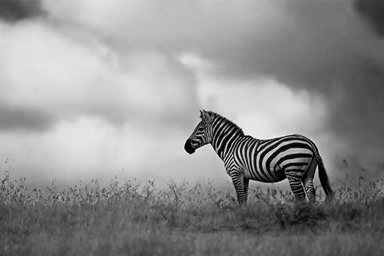

In [ ]:
# path = "/content/drive/MyDrive/Group-6/CASIA2/Au/Au_ani_00001.jpg"
# image = Image.open(path)
# image.getchannel(0)

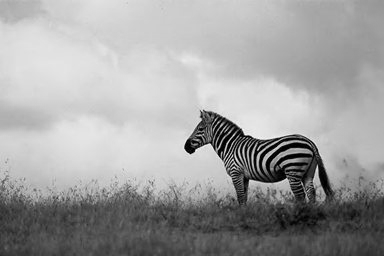

In [ ]:
# image.getchannel(1)

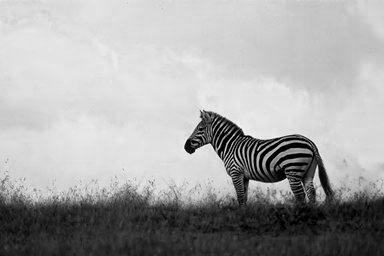

In [ ]:
# image.getchannel(2)

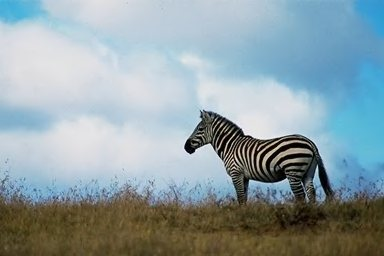

In [ ]:
# image

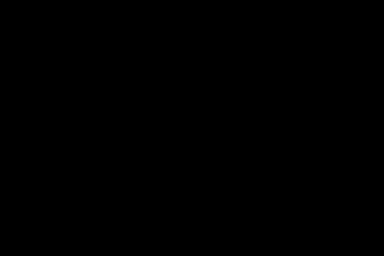

In [ ]:
# differ_image = ImageChops.difference(image,image)
# differ_image

In [ ]:
# jpeg_img = Image.open("/content/temp.jpg")

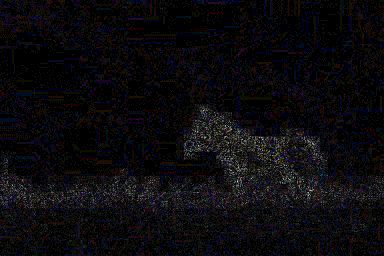

In [ ]:
# differ_image = ImageChops.difference(image,jpeg_img)
# brighten_diff_image = ImageEnhance.Brightness(differ_image).enhance((255.0/16))
# brighten_diff_image

In [ ]:
# extrema = differ_image.getextrema()
# extrema

((0, 14), (0, 14), (0, 15))

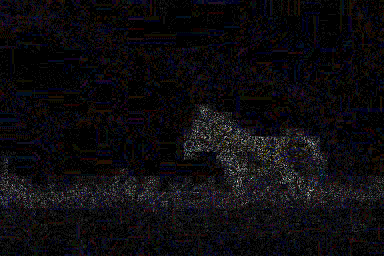

In [ ]:
# path = "/content/drive/MyDrive/Group-6/CASIA2/Au/Au_ani_00001.jpg"
# ela_image = convert_to_ela_image(path,90)
# ela_image

array([[[15,  0, 15],
        [15,  0, 15],
        [15,  0,  0],
        ...,
        [ 0,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  0]],

       [[ 0, 15, 30],
        [15,  0, 15],
        [15,  0,  0],
        ...,
        [15, 15, 15],
        [15, 15, 15],
        [ 0,  0,  0]],

       [[ 0, 15, 15],
        [15,  0,  0],
        [15, 15, 30],
        ...,
        [30, 30, 15],
        [15, 15,  0],
        [30, 30, 15]],

       ...,

       [[ 0, 15,  0],
        [15, 30, 15],
        [ 0, 15,  0],
        ...,
        [45, 15,  0],
        [15, 15, 15],
        [15, 15, 15]],

       [[ 0, 15,  0],
        [15, 30, 15],
        [15, 30, 15],
        ...,
        [30,  0, 15],
        [15, 15, 15],
        [15, 15, 15]],

       [[30, 15, 30],
        [ 0, 15,  0],
        [15, 30, 15],
        ...,
        [ 0, 30, 15],
        [ 0,  0,  0],
        [15, 15, 15]]], dtype=uint8)
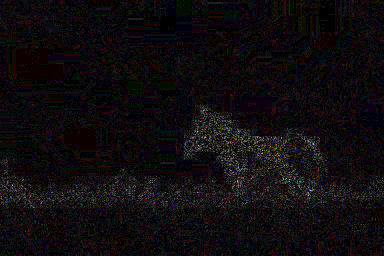

**Generating random samples**

In [ ]:
def random_sample(path, extension=None):
    if extension:
        items = Path(path).glob(f'*.{extension}')
    else:
        items = Path(path).glob(f'*')

    items = list(items)

    p = random.choice(items)
    return p.as_posix()

**Preprocessing**

In [ ]:
image_size= (128,128)

In [ ]:
def apply_train_transformations(image_path):
    image = Image.open(image_path)
    image = tf.image.rot90(image)
    image = tf.image.random_crop(image,(224,224,3))
    image = tf.image.flip_left_right(image)

    return image

def apply_test_transformations(image_path):
    image = Image.open(image_path)
    image = tf.image.resize(image,image_size)
    image = tf.image.central_crop(image,0.5)
    return image



def prepare_image(original_image):

    image_size= (128,128)
    #loading original image
    # original_image = Image.open(image_path)

    # Convert the image to ELA image
    # ela_image = convert_to_ela_image(image_path, 100)
    original_image = tf.image.resize(original_image,image_size)
    # Convert the resized ELA image to a NumPy array and normalize
    image = np.array(original_image).astype(np.float32) / 255.0



    # Add noise residuals using the SRM technique
    srm_residuals = compute_srm_residuals(image)
    image_with_srm = image + srm_residuals

    return image_with_srm

def compute_srm_residuals(image):
    # Compute the noise residuals using the SRM technique
    sigma_estimation = estimate_sigma(image,average_sigmas=True,channel_axis=-1)

    srm_residuals = denoise_wavelet(image, sigma=sigma_estimation, wavelet='haar', method='BayesShrink', mode='soft')

    return srm_residuals

**Creating Training and testing** **samples**

In [ ]:
X = [] # ELA converted images
Y = [] # 0 for fake, 1 for real
import random
path = '/content/drive/MyDrive/Group-6/CASIA1/Au'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('png') or filename.endswith('bmp'):
            full_path = os.path.join(dirname, filename)
            processed_image = apply_train_transformations(full_path)
            X.append(prepare_image(processed_image))
            Y.append(1)
            if len(Y) % 100 == 0:
                print(f'Processing {len(Y)} images')

random.shuffle(X)
X = X[:800]
Y = Y[:800]
print(len(X), len(Y))

Processing 100 images
Processing 200 images
Processing 300 images
Processing 400 images
Processing 500 images
Processing 600 images
Processing 700 images
790 790


In [ ]:
\

# print(X)

[array([[[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       ...,

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]],

       [[nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan],
        ...,
        [nan, nan, nan],
        [nan, nan, nan],
        [nan, nan, nan]

In [ ]:
path = '/content/drive/MyDrive/Group-6/CASIA1/Sp'
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('jpg') or filename.endswith('png') or filename.endswith('tif'):
            full_path = os.path.join(dirname, filename)
            image = apply_test_transformations(full_path)
            X.append(prepare_image(image))
            Y.append(0)
            if len(Y) % 100 == 0:
                print(f'Processing {len(Y)} images')

print(len(X), len(Y))

Processing 800 images
Processing 900 images
Processing 1000 images
Processing 1100 images
Processing 1200 images
Processing 1300 images
Processing 1400 images
Processing 1500 images
Processing 1600 images
Processing 1700 images
1721 1721


In [ ]:
# prompt: count images within a folder

import os

def count_images_in_folder(folder_path):
  """Counts the number of image files in a given folder.

  Args:
    folder_path: The path to the folder containing the images.

  Returns:
    The number of image files in the folder.
  """
  image_count = 0
  for filename in os.listdir(folder_path):
    if filename.endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp')):
      image_count += 1
  return image_count

# Example usage:
folder_path = '/content/drive/MyDrive/Group-6/CASIA1/Sp'  # Replace with your folder path
image_count = count_images_in_folder(folder_path)
print(f"The folder '{folder_path}' contains {image_count} image files.")


The folder '/content/drive/MyDrive/Group-6/CASIA1/Sp' contains 931 image files.


In [ ]:
# path = "/content/drive/MyDrive/Group-6/CASIA2/Au/Au_ani_00003.jpg"
# image = Image.open(path).convert('RGB')
#     # Convert the image to ELA image
# ela_image = convert_to_ela_image(path, 91)

#     # Resize the ELA image
# resized_ela_image = ela_image.resize(image_size)

#     # Convert the resized ELA image to a NumPy array and normalize
# image = np.array(resized_ela_image).astype(np.float32) / 255.0
# srm_residues = compute_srm_residuals(image)
# print(srm_residues)

In [ ]:
# path = "/content/drive/MyDrive/Group-6/CASIA2/Au/Au_ani_00003.jpg"
# image = prepare_image(path)

(128, 128, 3)


<ipython-input-61-e1cc37d681e1>:21: UserWarning: image is size 3 on the last axis, but channel_axis is None. If this is a color image, please set channel_axis=-1 for proper noise estimation.
  sigma_estimation = estimate_sigma(image,average_sigmas=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 33.1 MB/s eta 0:00:00


In [ ]:
# prepare_image("/content/drive/MyDrive/Group-6/CASIA2/Au/Au_ani_00003.jpg")

(128, 128, 3)


<ipython-input-5-e1cc37d681e1>:21: UserWarning: image is size 3 on the last axis, but channel_axis is None. If this is a color image, please set channel_axis=-1 for proper noise estimation.
  sigma_estimation = estimate_sigma(image,average_sigmas=True)


array([[[0.2653026 , 0.20608526, 0.19255668],
        [0.168789  , 0.13974604, 0.06407145],
        [0.13374746, 0.14210501, 0.09379013],
        ...,
        [0.11090434, 0.14312416, 0.37294883],
        [0.17835945, 0.16267318, 0.23963395],
        [0.14101379, 0.15670006, 0.22875886]],

       [[0.0839283 , 0.05245315, 0.10348484],
        [0.12092957, 0.13139348, 0.1026321 ],
        [0.12459855, 0.14472082, 0.11797456],
        ...,
        [0.19605461, 0.2204313 , 0.15054366],
        [0.07360134, 0.07360134, 0.16624838],
        [0.09526072, 0.09918229, 0.17320189]],

       [[0.03349025, 0.0519846 , 0.07410997],
        [0.16393629, 0.20203847, 0.2261246 ],
        [0.05799844, 0.07798758, 0.07125954],
        ...,
        [0.10336755, 0.1347401 , 0.14834827],
        [0.0910276 , 0.07502094, 0.20259519],
        [0.08245771, 0.0460806 , 0.06626683]],

       ...,

       [[0.345119  , 0.41700798, 0.35361248],
        [0.32500216, 0.45451653, 0.4015241 ],
        [0.30888325, 0

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# Convert X from a list to a NumPy array
X = np.array(X)



# Perform PCA for dimensionality reduction
# pca = PCA(n_components=100)  # Set the number of components to keep
# X_pca = pca.fit_transform(X.reshape(X.shape[0], -1))

# Convert Y to categorical
Y = to_categorical(Y, 2)
X = X.reshape(-1, 128, 128, 3)

In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size = 0.2, random_state=5)
X = X.reshape(-1,1,1,1)
print(len(X_train), len(Y_train))
print(len(X_val), len(Y_val))

1376 1376
345 345


**Training**

*VGG16*

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the VGG16 model with pre-trained weights
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Unfreeze the top convolutional blocks
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
# Add your own classification layers
x = Flatten()(vgg_base.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)

# Create the final model
model = Model(inputs=vgg_base.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


# Train the model
history_16 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=32)

# Evaluate the model
loss_16, accuracy_16 = model.evaluate(X_val, Y_val)

# Make predictions on the validation data
Y_pred = model.predict(X_val)

# Convert predictions to class labels
Y_pred_labels = np.argmax(Y_pred, axis=1)
Y_val_labels = np.argmax(Y_val, axis=1)

# Calculate precision, recall, and F1 score
precision_16 = precision_score(Y_val_labels, Y_pred_labels, average='weighted')
recall_16 = recall_score(Y_val_labels, Y_pred_labels, average='weighted')
f1_16 = f1_score(Y_val_labels, Y_pred_labels, average='weighted')

print("Validation Loss:", loss_16)
print("Validation Accuracy:", accuracy_16)
print("Precision:", precision_16)
print("Recall:", recall_16)
print("F1 Score:", f1_16)



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 16,812,610 (64.14 MB)

 Trainable params: 9,177,346 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 25s 316ms/step - accuracy: 0.8113 - loss: 0.4228 - val_accuracy: 0.9652 - val_loss: 0.0764
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.9851 - loss: 0.0441 - val_accuracy: 0.9884 - val_loss: 0.0323
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9963 - loss: 0.0135 - val_accuracy: 0.9681 - val_loss: 0.0793
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.9973 - loss: 0.0082 - val_accuracy: 0.9391 - val_loss: 0.1957
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9913 - loss: 0.0328 - val_accuracy: 0.9797 - val_loss: 0.0622
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 1.0000 - loss: 4.8997e-04 - val_accuracy: 0.9855 - val_loss: 0.0547
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 1.0000 - loss: 1.3087e-04 - val_accuracy: 0.9855 - val_loss: 0.0557
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 1.0000 - loss: 5.2111e-05 - val_accur

In [ ]:
# prompt: write a code to create a graph for the training history in vgg16

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history_16.history['accuracy'])
plt.plot(history_16.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history_16.history['loss'])
plt.plot(history_16.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

NameError: name 'history_16' is not defined

<Figure size 1000x500 with 0 Axes>

*DENSENET121*

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score
# Load the DenseNet121 model with pre-trained weights
dense_base = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Unfreeze the top convolutional blocks
for layer in dense_base.layers[:-4]:
    layer.trainable = False
# Add your own classification layers
x = Flatten()(dense_base.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)

# Create the final model
model = Model(inputs=dense_base.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


# Train the model
history_121 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=10)

# Evaluate the model
loss_121, accuracy_121 = model.evaluate(X_val, Y_val)

# Make predictions on the validation data
Y_pred = model.predict(X_val)

# Convert predictions to class labels
Y_pred_labels = np.argmax(Y_pred, axis=1)
Y_val_labels = np.argmax(Y_val, axis=1)

# Calculate precision, recall, and F1 score
precision_121 = precision_score(Y_val_labels, Y_pred_labels, average='weighted')
recall_121 = recall_score(Y_val_labels, Y_pred_labels, average='weighted')
f1_121 = f1_score(Y_val_labels, Y_pred_labels, average='weighted')

print("Validation Loss:", loss_121)
print("Validation Accuracy:", accuracy_121)
print("Precision:", precision_121)
print("Recall:", recall_121)
print("F1 Score:", f1_121)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_2          │ (None, 134, 134, 3)    │              0 │ input_layer_1[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 64, 64, 64)     │          9,408 │ zero_padding2d_2[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 64, 64, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 64, 64, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_3          │ (None, 66, 66, 64)     │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 32, 32, 64)     │              0 │ zero_padding2d_3[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 32, 32, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 32, 32, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 32, 32, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 32, 32, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 32, 32, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 32, 32, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 32, 32, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├──────────────────────

 Total params: 11,232,578 (42.85 MB)

 Trainable params: 4,233,986 (16.15 MB)

 Non-trainable params: 6,998,592 (26.70 MB)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 52s 205ms/step - accuracy: 0.7677 - loss: 0.5322 - val_accuracy: 0.9333 - val_loss: 0.1506
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9547 - loss: 0.1199 - val_accuracy: 0.9739 - val_loss: 0.0897
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9855 - loss: 0.0567 - val_accuracy: 0.9681 - val_loss: 0.0912
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9890 - loss: 0.0445 - val_accuracy: 0.9536 - val_loss: 0.1404
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9777 - loss: 0.0614 - val_accuracy: 0.9768 - val_loss: 0.0839
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9850 - loss: 0.0449 - val_accuracy: 0.9710 - val_loss: 0.0669
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9829 - loss: 0.0475 - val_accuracy: 0.9710 - val_loss: 0.0653
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9969 - loss: 0.0133 - val_ac

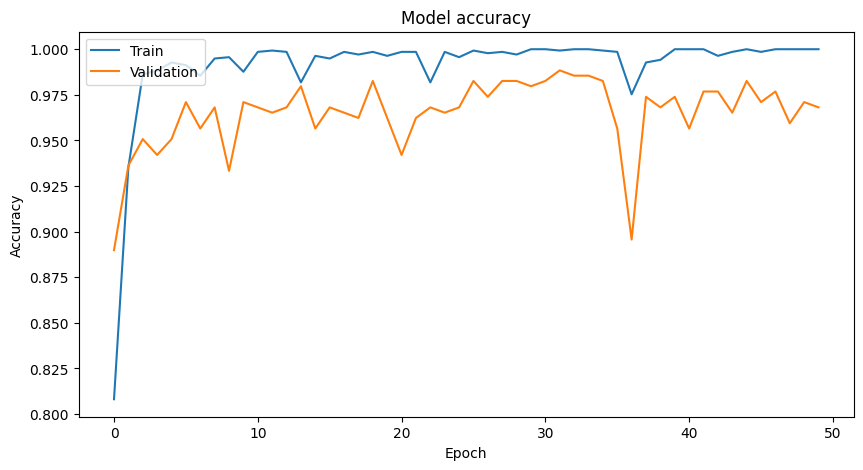

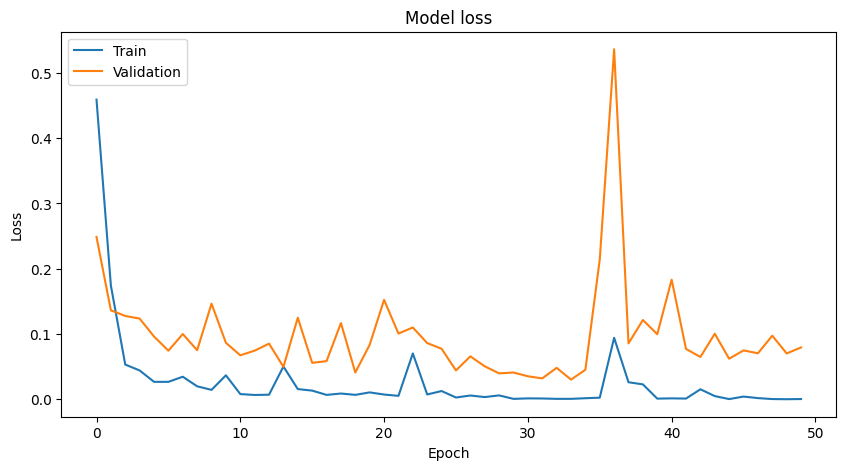

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history_121.history['accuracy'])
plt.plot(history_121.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history_121.history['loss'])
plt.plot(history_121.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model.save("densenet121.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 907ms/step
[[1.2932377e-37 1.0000000e+00]]


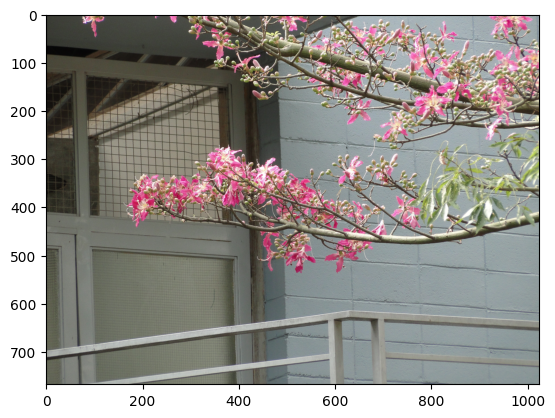

(0.0, 1.0, 0.0, 1.0)

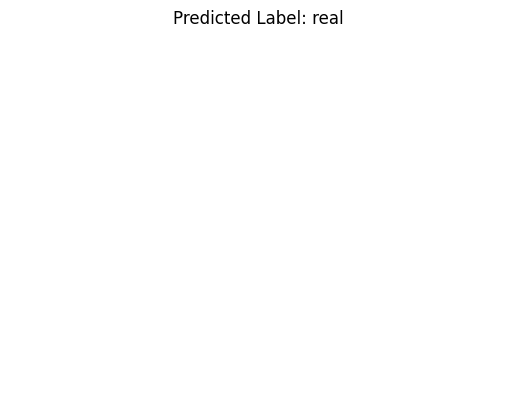

In [ ]:
path = "/content/000bc3906100ede4b1374cea075adedb.png"
image = Image.open(path)
prediction = model.predict(prepare_image(image).reshape(-1,128,128,3))
print(prediction)
predicted_class = np.argmax(prediction)
class_labels = ["fake", "real"]
predicted_label = class_labels[predicted_class]
# print(predicted_label)

show_image = Image.open(path)
plt.imshow(show_image)
plt.show()
plt.title(f"Predicted Label: {predicted_label}")
plt.axis("off")




1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
[[1.0000000e+00 2.0874604e-12]]
fake


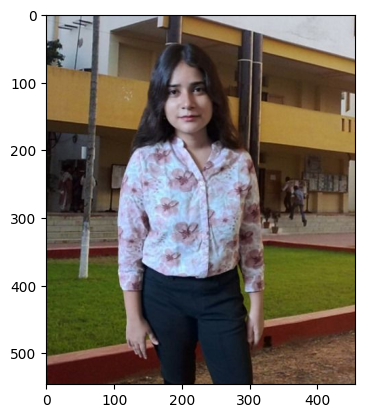

(0.0, 1.0, 0.0, 1.0)

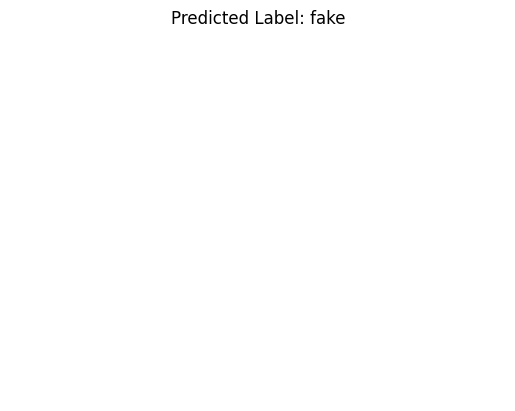

In [ ]:
path = "/content/fakeimage.jpg"
image = Image.open(path)
prediction = model.predict(prepare_image(image).reshape(-1,128,128,3))
print(prediction)
predicted_class = np.argmax(prediction)
class_labels = ["fake", "real"]
predicted_label = class_labels[predicted_class]
print(predicted_label)

show_image = Image.open(path)
plt.imshow(show_image)
plt.show()
plt.title(f"Predicted Label: {predicted_label}")
plt.axis("off")

*VGG19*

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the VGG19 model with pre-trained weights
vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Unfreeze the top convolutional blocks
for layer in vgg19_base.layers[:-4]:
    layer.trainable = False
# Add your own classification layers
x = Flatten()(vgg19_base.output)
x = Dense(256, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)

# Create the final model
model = Model(inputs=vgg19_base.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-6),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


# Train the model
history_19 = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=50, batch_size=32)

# Evaluate the model
loss_19, accuracy_19 = model.evaluate(X_val, Y_val)

# Make predictions on the validation data
Y_pred = model.predict(X_val)

# Convert predictions to class labels
Y_pred_labels = np.argmax(Y_pred, axis=1)
Y_val_labels = np.argmax(Y_val, axis=1)

# Calculate precision, recall, and F1 score
precision_19 = precision_score(Y_val_labels, Y_pred_labels, average='weighted')
recall_19 = recall_score(Y_val_labels, Y_pred_labels, average='weighted')
f1_19 = f1_score(Y_val_labels, Y_pred_labels, average='weighted')

print("Validation Loss:", loss_19)
print("Validation Accuracy:", accuracy_19)
print("Precision:", precision_19)
print("Recall:", recall_19)
print("F1 Score:", f1_19)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 22,122,306 (84.39 MB)

 Trainable params: 9,177,346 (35.01 MB)

 Non-trainable params: 12,944,960 (49.38 MB)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.5983 - loss: 0.6991 - val_accuracy: 0.6493 - val_loss: 0.6609
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.6733 - loss: 0.6516 - val_accuracy: 0.7130 - val_loss: 0.6384
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.7609 - loss: 0.6100 - val_accuracy: 0.7420 - val_loss: 0.6170
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8120 - loss: 0.5807 - val_accuracy: 0.7623 - val_loss: 0.5953
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.8158 - loss: 0.5625 - val_accuracy: 0.7797 - val_loss: 0.5718
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.8197 - loss: 0.5411 - val_accuracy: 0.7855 - val_loss: 0.5483
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - accuracy: 0.8682 - loss: 0.5019 - val_accuracy: 0.8000 - val_loss: 0.5230
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8892 - loss: 0.4587 - val_accuracy: 0.8174 - 

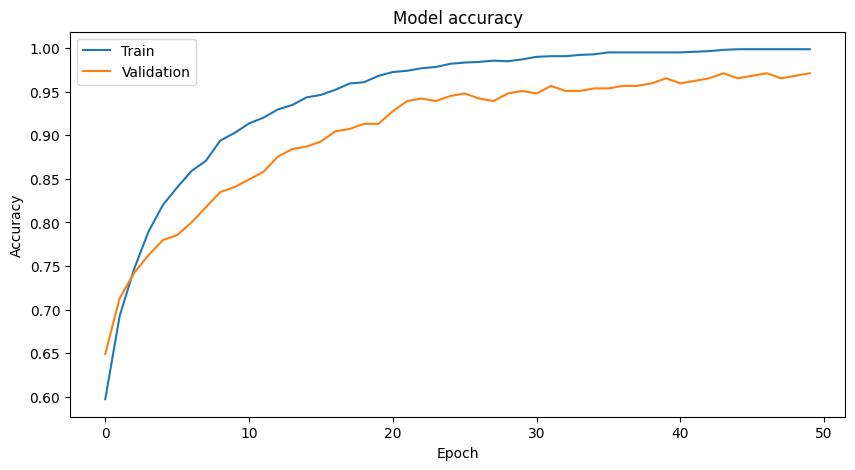

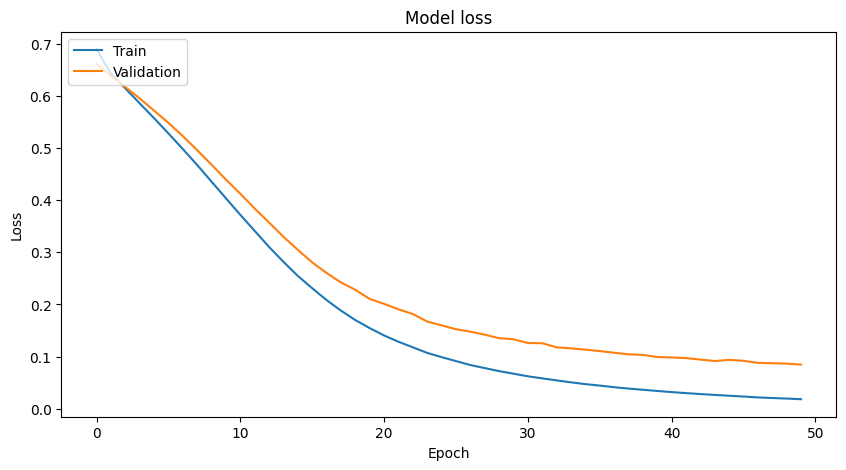

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 5))
plt.plot(history_19.history['accuracy'])
plt.plot(history_19.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 5))
plt.plot(history_19.history['loss'])
plt.plot(history_19.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()